In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
# Merged and deduplicated sentences (Ground Truth)
merged_ground_truth_sentences = [
"he / king gives birth / begets life life (ankh) above horizon sky",
"god / deity great / mighty power stability (djed) throne temple city / town",
"man eat / drink / speak loaf of bread milk jar water ripple peace / satisfy",
"father mother love child life house gate door bolt peace / content (satisfied)",
"seated king holds authority power throne temple people city / town",
"soul (ba) emerge from body face / upon sky star west",
"scribe writing / scribe book papyrus scroll reed leaf knowledge power authority",
"god opens / exists (or is found) gate horizon sun sky life (ankh)",
"man plows (tills) field grain / pellet harvest abundance life peace",
"king sees people hear / listen fear power authority law",
"woman gives birth / begets child youth life house love",
"river flows from mountain hill desert field life",
"offering loaf of bread conical loaf (give) jar incense temple god",
"heart truth feather (truth/maat) balance judgment soul (ba)",
"storm fire power destruction fear people city / town",
"old man wisdom authority teaching people life path",
"snake coil of rope fear power protection god",
"house gate opens / exists (or is found) people enter peace",
"king travels road town city / town authority power",
"night sky star thousand beauty wonder life",
"god / deity emerges horizon sky life (ankh) power great / big",
"king hears people speak truth authority law stability (djed)",
"woman carries water jar house life peace sweet",
"man sees snake fear heart strength / force protection",
"scribe writes book papyrus scroll knowledge power authority",
"riverbank field grain / pellet harvest abundance life people",
"temple gate opens god enters peace altar offering",
"father teaches youth wisdom life path strength / force",
"king sits throne authority power people city / town",
"mountain hill desert silence fear beauty sky",
"soul (ba) travels west underground star life rebirth",
"man eats bread drinks water life strength / force",
"mother loves child gives birth / begets life joy",
"storm crosses sky fire power fear destruction",
"god gives life (ankh) power authority king throne",
"people gather temple offering peace god blessing",
"road leads town city / town people trade life",
"heart desires peace love life satisfaction joy",
"lake reflects sky star beauty calm peace",
"snake protects house gate fear power magic",
"god / deity gives birth / begets life (ankh) people city / town temple authority power great / mighty peace / content (satisfied)",
"he / king seated god / king throne authority power people town stability (djed)",
"man eat / drink / speak loaf of bread water ripple life strength / force heart peace / satisfy",
"woman seated woman house gate door bolt life love peace / content (satisfied)",
"scribe writing / scribe papyrus scroll reed leaf book authority power thing",
"river riverbank field grain / pellet people life abundance peace / satisfy",
"soul (ba) emerge west underground star sky life to become",
"father mother man woman people house life love peace",
"storm fire sky power fear destruction city / town people",
"offering loaf of bread conical loaf (give) jar vessel temple god peace / altar",
"man sees eye face / upon sky star sweet life heart love",
"he / king opens / exists (or is found) gate house people peace / content (satisfied) authority power life great / mighty",
"woman to give milk jar youth life love peace / content (satisfied) sweet house heart",
"writing / scribe do papyrus scroll reed leaf book thing power authority great / big life",
"soul (ba) to return / retreat west underground star sky life to become power great",
"man plows (repeated) field grain / pellet life people peace / satisfy great / big strength / force heart",
"offering to give loaf of bread jar vessel god temple peace / altar life power",
"mountain hill slope river lake water ripple life peace / content (satisfied) sweet sky great / big",
"sedge (king) authority power throne seat / throne people city / town stability (djed) great / mighty life",
"heart fear storm fire strength / force man life to become power great / big",
"owl sees sky star thousand beautiful / good sweet life peace / content (satisfied) heart",
"quail chick hear / listen people eat / drink / speak feather (truth/maat) authority power stability (djed) he / king throne",
"scarab / become to become life soul (ba) west underground star sky horizon great / mighty",
"reed shelter house gate opens / exists (or is found) people life peace / satisfy sweet heart beautiful / good",
"old man pillar / grandfather authority people life heart power great / big stability (djed) throne",
"river road town city / town people life power strength / force heart great / mighty",
"lotus plant lake water ripple beautiful / good life peace / content (satisfied) sweet sky heart love",
"senet board seated man people life peace / content (satisfied) sweet heart great / big power authority",
"cobra snake fear power protection house gate people life strength / force",
"papyrus clump plant field life water ripple peace / content (satisfied) sweet beautiful / good",
"seated man (i / me) do offering loaf of bread jar temple god peace / altar",
"sedge (king) he / king power authority throne stability (djed) people city / town",
"eye sees face / upon beauty truth feather (truth/maat) heart peace life",
"river flows west underground life soul (ba) to become star sky",
"mother woman gives birth / begets youth life house love peace sweet",
"mountain desert hill horizon sky star fear power strength / force",
"head of ox strength / force power god temple offering peace / altar life authority",
"head of bird sees sky horizon star life soul (ba) to become",
"hand gives to give loaf of bread offering temple god peace / altar",
"forearm hand power strength / force work do life people",
"foot walks road town city / town people life journey power",
"mouth eat / drink / speak truth feather (truth/maat) heart peace authority",
"horned viper fear power protection god house gate life",
"reed leaf writing / scribe papyrus scroll book knowledge authority power",
"rope tethering rope animal belly control power strength / force stability (djed)",
"stool / mat seated man rest peace / content (satisfied) life house heart",
"gate opens / exists (or is found) road town people do life peace authority power",
"scarab / become heart soul (ba) life to become power strength / force great / mighty stability (djed) sky",
"lake water ripple lotus plant life peace sweet beautiful / good sky heart love",
"plows (tills) field grain / pellet people life strength / force peace great / big heart power",
"papyrus scroll writing / scribe book thing authority power life heart peace beautiful / good",
"west underground mountain soul (ba) life star sky to become horizon power",
"servant people house do hand life power authority peace great / big",
"temple pillar / grandfather god authority power stability (djed) peace life great / mighty sky",
"basket with handle lord / every offering loaf of bread temple god peace / altar life power authority",
"jar jars in rack house people life grain / pellet peace / content (satisfied) sweet beautiful / good heart",
"cross cut stone chisel do hand strength / force power great / big authority",
"club fear people city / town power authority strength / force strong great / mighty stability (djed)",
"milk jar mother youth life love sweet house peace / content (satisfied) heart beautiful / good",
"river riverbank people sees life water ripple peace / satisfy heart beautiful / good sweet",
"papyrus clump reed shelter house people life peace / content (satisfied) sweet beautiful / good heart great / big",
"ring power authority throne seat / throne sedge (king) people city / town stability (djed) great / mighty",
"three fox skins fear power strength / force god temple offering life peace / altar authority",
"basket with handle offering loaf of bread jar vessel temple god peace / altar life authority",
"adze chisel cut stone house gate city / town authority power do",
"door bolt gate house fear people authority power strength / force life peace / content (satisfied)",
"negation (no/not) do eat / drink / speak offering life peace / satisfy heart people house god",
"ka (spirit) ka (the spirit / the double) life power strength / force god soul (ba) peace / content (satisfied) sky star",
"ring authority power lord / every master (lord) / all (every) people life stability (djed) throne great / mighty",
"vessel jar milk jar offering mother woman life love house peace / content (satisfied)",
"basket (lord / all) lord / every offering to give temple god peace / altar life power authority",
"three fox skins fear power strength / force god house gate life authority great / mighty",
"ka (spirit) soul (ba) life to become west underground star sky horizon power",
"negation (no/not) fear heart peace / satisfy life sweet beautiful / good peace / content (satisfied) man woman",
"placenta gives birth / begets life mother woman house love peace sweet heart",
"single stroke stroke (plural marker) thousand people city / town power authority great / big life strength / force",
"swallow (great) sky star thousand beautiful / good life sweet heart peace / content (atisfied) soul (ba)",
"venerated / marrow old man authority heart life power stability (djed) great / mighty people temple",
"great god gives birth to beautiful youth above desert hill",
"seated man hears heart like mother bird head behind house",
"lord of every city opens gate for people to become",
"venerated father hears truth from feather of maat in temple",
"strong king plows field with hoe near riverbank and lake",
"seated woman loves beautiful life under sky and star light",
"mighty authority of god gives peace to every house heart",
"scribe do writing on papyrus scroll for master of all",
"horned viper and cobra emerge from stone under brick wall",
"old man hears soul ba of great god behind mountain",
"servant give loaf of bread and jar to thirsty man",
"scarab become great power on throne above every seated king",
"swallow bird fly above horizon like soul to become star",
"spirit ka of mother sees beautiful face of youth heart",
"mighty storm on riverbank make people fear power of sky",
"lord of life do offering on altar for peace content",
"hand of king do great thing for city and town",
"cobra and snake emerge from basket with handle behind brick",
"scribe hear truth and do writing for god in temple",
"great king give life to people like father to youth",
"seated god on throne give power to king in house",
"quail chick and swallow bird fly above desert hill slope",
"great scribe do writing on stone with chisel and hand",
"mother gives birth to youth with heart of great god",
"man eat loaf of bread and drink from milk jar",
"basket with handle hold grain and loaf for every people",
"spirit ka of father sees eye of truth in temple",
"servant plows field near river with hoe and strong backbone",
"master of all hear heart of seated man behind gate",
"star and sky give light to city and town underground",
"lord of life do offering of lotus plant and water",
"mighty authority of king become great like mountain above river",
"folded cloth and rope stay in basket behind door bolt",
"horned viper and snake hide in brick near temple wall",
"beautiful youth become old man with power of spirit ka",
"great fire in hearth give peace to people in house",
"scribe hear truth and do writing for king on throne",
"hand of god give life ankh to lord of horizon",
"animal belly and side rib of ox stay on altar",
"venerated master hear soul ba of youth in great city",
"scribe use adze and chisel on stone in great city",
"man play senet board and drink from jar in house",
"quail chick hide in papyrus clump near river and lake",
"king on throne give order to servant with strong backbone",
"beautiful lotus plant grow in water near gate of temple",
"lord of every town hear truth from mouth of people",
"great storm above mountain make fear in heart of man",
"mother and youth eat loaf of bread near desert hill",
"spirit ka of king become star in sky above horizon",
"seated woman do writing on papyrus scroll with reed leaf",
"mighty cobra and horned viper stay behind brick in desert",
"venerated father give life ankh to beautiful child in house",
"servant of god do offering of milk jar on altar",
"great mountain and desert hill slope stay behind the riverbank",
"scribe hear voice of master and do writing of thing",
"hand of man hold coil of rope and tethering rope",
"sweet water from river give life to every animal belly",
"gate of horizon opens for soul ba of great king",
"man with hoe plows field and becomes master of grain",
"seated god on throne sees truth of heart in temple",
"reed shelter on riverbank give peace to every seated man",
"twisted flax and coil of rope stay in the basket",
"great king of city use power to do beautiful thing",
"vessel on river carry grain and loaf to the town",
"scribe use reed leaf to do writing on papyrus scroll",
"door bolt of temple opens for the soul of god",
"seated woman in house hear voice of the quail chick",
"mighty authority of master become great like the mountain side",
"father and mother give beautiful thing to the young youth",
"horned viper in desert hill slope make fear in people",
"man with chisel and adze do work on stone brick",
"spirit ka of god sees heart of lord in temple",
"lotus plant in lake become beautiful in the sky light",
"servant carry milk jar and bread to the old man",
"great fire in desert make the horizon become very red",
"hand of scribe do writing of truth for the king",
"venerated master of all give offering on the stone altar",
"snake and cobra emerge from the field near the road",
"sweet milk in jar give strength to the animal belly",
"soul ba of king fly like swallow to the star",
"sedge king on throne hear truth from the old man",
"man use three fox skins to make beautiful folded cloth",
"great storm above the riverbank make the stone wall fall",
"scribe of town do writing of grain in the book",
"seated god gives birth to the spirit ka of king",
"servant use door bolt to lock the house of lord",
"quail chick and swallow bird fly to the reed shelter",
"mighty power of authority stay with the master of city",
"old man drink sweet milk from the jar in temple",
"venerated father sees the star above the desert hill slope",
"man play senet board while he eat loaf of bread",
"chisel and adze stay on the brick in the field",
"spirit ka of mother loves the heart of beautiful youth",
"cobra and horned viper stay under the lotus plant leaf",
"great fire in temple give light to the seated god",
"hand of king do offering of bread on stone altar",
"soul ba of people fly to the sky like bird",
"scribe hear mouth of god and do writing of truth",
"mighty mountain and desert hill stay behind the great river",
"lord of every town give peace to the seated woman",
"man use sickle to cut grain in the great field",
"vessel on river carry papyrus scroll to the scribe house",
"mighty backbone of king give strength to the whole city",
"seated god in temple hear the heart of every man",
"mother give beautiful lotus plant to the youth in house",
"lord of horizon do great thing for the spirit ka",
"venerated father eat loaf of bread near the reed shelter",
"old man and woman see the star in the sky",
"scribe do writing of truth with reed leaf on papyrus",
"great storm above lake make the people fear the god",
"cobra and snake hide under the stone in the desert",
"hand of king hold the authority of the great town",
"servant give sweet milk jar to the master of all",
"spirit ka of youth become strong like the desert hill",
"gate of the city stay behind the big brick wall",
"soul ba of father fly above the mountain like bird",
"man with adze and chisel work on the seat throne",
"lord of life ankh give peace to the seated woman",
"three fox skins stay in the basket with the handle",
"mouth of god speak to the heart of the king",
"pillar grandfather stay strong in the gate of the temple",
"man give conical loaf and milk jar to the god",
"placenta of mother stay in the house of beautiful youth",
"great king use power to become master of the road",
"scribe hear mouth of people and do writing of law",
"seated woman use basket with handle to carry the grain",
"mighty authority of lord stay above the city and town",
"soul ba of father fly like swallow to the mountain",
"servant of king do offering of fire on the altar",
"venerated master hear the heart of every man and woman",
"horned viper and cobra hide behind the stone brick wall",
"old man with backbone of strength plows the great field",
"beautiful lotus plant grow near the water of the lake",
"scribe use chisel to do writing on the stone throne",
"spirit ka of god give life ankh to the people",
"hand of youth hold reed leaf in the reed shelter",
"great storm above the desert hill make the sky dark",
"lord of all give loaf of bread to the servant",
"swallow bird and quail chick fly above the papyrus clump",
"seated god sees the truth in the heart of king",
"jars in rack stay in the house of the scribe",
"man play senet board while the woman eat sweet bread",
"mighty backbone of king give stability djed to the land",
"hand of servant carry animal belly to the great altar",
"beautiful lotus plant and papyrus clump grow near the lake",
"venerated father hear the voice of the soul ba bird",
"lord of every town do offering for the seated god",
"scribe use chisel and stone to make the temple gate",
"strong storm above the riverbank make the people fear life",
"old man with hoe plows the field near the mountain",
"spirit ka of mother give love to the beautiful youth",
"horned viper and cobra hide in the basket with handle",
"king on throne give life ankh to the seated man",
"door bolt of the city stay strong behind the wall",
"scribe hear mouth of master and do writing of thing",
"mother gives birth to youth under the star of sky",
"sweet water from the river give life to the plant",
"vessel on the water carry grain to the great city",
"seated god sees the heart and truth of every person",
"man with three fox skins stay behind the reed shelter",
"negation no man can hide from the eye of god",
"animal belly and side rib of ox stay on altar",
"great king of city use power to become master lord",
"venerated father hear voice of mother in the stone house",
"scribe of town do writing of grain on papyrus scroll",
"seated god give peace content to the heart of people",
"mighty authority of master stay strong above the desert hill",
"servant carry milk jar and conical loaf to the king",
"old man with backbone of strength plows the riverbank field",
"beautiful lotus plant in lake become sweet to the spirit",
"horned viper and cobra emerge from the brick behind gate",
"spirit ka of youth see the star in sky light",
"hand of scribe hold reed leaf to do writing thing",
"soul ba of king fly like swallow bird to horizon",
"mother gives birth to youth near the great papyrus clump",
"lord of every city give life ankh to the people",
"chisel and adze stay in basket with handle near stone",
"sweet water from river ripple give life to the plant",
"seated woman loves the beautiful face of the young youth",
"great storm above the city make the sky become dark",
"man use folded cloth to cover the beautiful senet board",
"negation no spirit ka can stay behind the gate forever",
"mighty authority of the king stay above the desert hill",
"venerated master hear the truth from the mouth of scribe",
"servant carry the basket with handle to the great house",
"old man and youth drink sweet milk from the jar",
"hand of god give life ankh to the seated king",
"mother loves the beautiful youth with the heart of gold",
"horned viper and cobra hide in the stone brick wall",
"scribe do writing of the thing on the papyrus scroll",
"lord of life do offering of the lotus plant altar",
"quail chick and swallow fly to the great papyrus clump",
"spirit ka of the father sees the face of mother",
"strong man with the hoe plows the field near river",
"soul ba of the people fly like bird to sky",
"chisel and adze stay on the stool mat in temple",
"seated woman loves the beautiful song of the swallow bird",
"king on the throne give power to the great town",
"sweet water from the lake give life to the animal",
"man use twisted flax to make rope for the vessel",
"great king of the city becomes lord of the road",
"scribe of the town hear truth and do writing thing",
"mother give beautiful lotus plant and milk jar to youth",
"spirit ka of the master stay in the stone house",
"lord of life ankh give peace to the seated woman",
"old man with the backbone of strength plows the field",
"swallow bird fly above the horizon like the soul ba",
"mighty authority of the god stay above the desert hill",
"servant carry the conical loaf to the great seated king",
"hand of the scribe hold reed leaf for papyrus scroll",
"horned viper and cobra hide behind the brick wall gate",
"seated god in the temple sees the heart of people",
"quail chick hide in the papyrus clump near the river",
"venerated father hear the voice of the beautiful young youth",
"strong storm on the riverbank make the people fear power",
"chisel and adze stay on the stone near the temple",
"head of bird and head of ox stay on altar",
"gate of the horizon opens for the spirit of king",
"man use three fox skins to make beautiful folded cloth",
"scribe do writing of the thing on the papyrus scroll",
"mother see the placenta of the youth in the house",
"lord of the city play the senet board with master",
"hand of the servant hold the tethering rope of vessel",
"great king on the throne gives birth to the law",
"venerated father hear the heart of the soul ba bird",
"strong storm above the desert hill make the sky dark",
"spirit ka of the god stay in the great temple",
"old man and woman drink from the milk jar house",
"cobra and horned viper hide in the basket with handle",
"mighty authority of the lord stay above the riverbank road",
"quail chick hide in the papyrus clump near the lake",
"chisel and adze stay on the stone brick in field",
"seated woman loves the beautiful lotus plant in the water",
"gate of the horizon opens for the great seated god",
"sweet loaf of bread give strength to the animal belly",
"servant of the king do offering on the stone altar",
"head of bird stay above the door bolt of temple",
"negation no man can hear the voice of the star",
"strong man plows repeated the field near the great river",
"scribe use reed leaf to do writing in the book",
"venerated lord stay in the seat throne above the city",
"spirit ka of the mother loves the beautiful young youth",
"mighty cobra and snake emerge from the basket with handle",
"hand of king hold the authority of the great god",
"old man hear the voice of the soul ba bird",
"servant carry the jar and loaf to the reed shelter",
"lotus plant and papyrus clump grow near the lake water",
"negation no fear stay in the heart of the king",
"chisel and adze stay on the stool mat in house",
"great storm above the mountain make the desert hill dark",
"seated woman drink sweet milk from the milk jar vessel",
"side rib of the animal stay on the stone altar",
"quail chick and swallow fly above the gate of temple",
"lord of all give life ankh to the seated man",
"horned viper hide in the brick near the door bolt",
"three fox skins stay on the back of the father",
"mother gives birth to the youth under the sky star",
"tethering rope hold the vessel near the great riverbank road",
"man use adze to make the seat throne of king",
"scribe hear mouth of god and do writing of truth",
"venerated father gives birth to the spirit ka of youth",
"mighty authority of the lord opens exists in the city",
"servant carry the conical loaf to the stone temple altar",
"old man and woman stay in the reed shelter house",
"hand of the scribe hold the papyrus scroll and leaf",
"spirit ka of mother sees the beautiful face of god",
"horned viper and cobra stay behind the brick wall gate",
"great storm above the horizon make the people fear life",
"strong man plows the field near the desert hill slope",
"swallow bird and quail chick fly to the papyrus clump",
"seated woman loves the beautiful lotus plant in the lake",
"lord of every town give life ankh to the people",
"chisel and adze stay in the basket with the handle",
"side rib and animal belly stay on the offering altar",
"soul ba of the father fly above the great mountain",
"sweet milk from the jar give strength to the youth",
"negation no snake can hide from the eye of king",
"tethering rope hold the vessel near the riverbank road stone",
"man use adze and chisel to make the seat throne",
"scribe of town do writing on the beautiful papyrus scroll",
"mother see placenta of the youth in the reed shelter",
"great king play the senet board in the stone house",
"hand of servant hold the basket with handle of grain",
"venerated father give the conical loaf to the seated god",
"spirit ka of the master stay strong above the city",
"mighty power of the authority stay with the great king",
"old man and woman eat the sweet loaf of bread",
"quail chick and swallow fly above the desert hill slope",
"horned viper and cobra hide behind the door bolt gate",
"strong man with the hoe plows the riverbank field road",
"seated woman loves the beautiful lotus plant and the star",
"chisel and adze stay on the stool mat in temple",
"three fox skins stay in the basket with the handle",
"soul ba of the father fly above the great mountain",
"sweet milk from the jar give strength to the youth",
"negation no man can hear the voice of the snake",
"tethering rope hold the vessel near the lake water ripple",
"man use adze to cut the head of bird ox",
"scribe do writing of truth on the papyrus scroll book",
"mother gives birth to youth in the house of life",
"great king of city becomes lord of every basket all",
"hand of servant carry milk jar to the seated god",
"venerated father hear the heart of the beautiful young youth",
"spirit ka of master stay above the great desert hill",
"mighty power of authority stay with the lord of life",
"old man drink sweet milk from the jar in temple",
"quail chick and swallow bird fly to the papyrus clump",
"horned viper and cobra hide under the brick wall stone",
"strong man with the hoe plows repeated the field road",
"seated woman loves the beautiful lotus plant in the lake",
"lord of every town give life ankh to the people",
"chisel and adze stay in the basket with the handle",
"animal belly and side rib stay on the offering altar",
"soul ba of father fly above the great mountain slope",
"sweet loaf of bread give strength to the youth heart",
"negation no snake can hide from the eye of king",
"tethering rope hold the vessel near the riverbank water ripple",
"sedge king play senet board with the old man master",
"man use the adze to cut the great mountain stone",
"scribe of town do writing of the thing on brick",
"mother see the heart of the youth in the house",
"hand of servant hold the milk jar and conical loaf",
"venerated father give the life ankh to the seated god",
"spirit ka of the lord stay above the desert hill",
"mighty authority of god stay with the head of bird",
"old man and woman stay in the great reed shelter",
"quail chick and swallow fly above the beautiful lotus plant",
"horned viper and cobra hide behind the door bolt gate",
"strong man with the hoe plows the field near lake",
"seated woman loves the beautiful face of the young youth",
"lord of every town give peace content to the people",
"chisel and adze stay on the stool mat in temple",
"animal belly and side rib stay in the basket handle",
"soul ba of father fly above the great riverbank road",
"sweet milk from the jar give strength to the heart",
"negation no snake can hide in the papyrus clump water",
"tethering rope hold the vessel near the great stone wall",
"man with backbone of strength use adze on the stone",
"three fox skins stay in the house of the scribe",
"sedge king on the throne gives birth to the law",
"man use adze to make the beautiful seat for god",
"scribe hear mouth of the people and do writing thing",
"mother see the placenta of the youth in the house",
"hand of servant hold the tethering rope of the vessel",
"venerated father and mother play the senet board in house",
"spirit ka of master stay above the great desert hill",
"mighty authority of lord stay with the head of bird",
"old man and woman stay in the great reed shelter",
"quail chick and swallow fly above the beautiful lotus plant",
"horned viper and cobra hide behind the door bolt gate",
"strong man with the hoe plows the field near lake",
"seated woman loves the beautiful face of the young youth",
"lord of every town give peace content to the people",
"chisel and adze stay on the stool mat in temple",
"animal belly and side rib stay in the basket handle",
"soul ba of father fly above the great riverbank road",
"sweet milk from the jar give strength to the heart",
"negation no man can hear the voice of the snake",
"three fox skins stay on the back of the servant",
"great king of the city becomes lord of every basket",
"man with the hoe plows tills the field near lake",
"scribe of town do writing of truth on papyrus scroll",
"hand of servant carry milk jar to the seated god",
"venerated father hear the voice of the soul ba bird",
"spirit ka of master stay above the great desert hill",
"mighty power of authority stay with the lord of life",
"old man drink sweet milk from the jar in temple",
"quail chick and swallow bird fly to the papyrus clump",
"horned viper and cobra hide under the brick wall stone",
"strong man with the adze make the seat throne throne",
"stability djed of the god stay in the great city",
"man use twisted flax to bind the great temple gate",
"scribe of town use reed leaf to do writing thing",
"mother gives birth to youth near the stone brick wall",
"great king of city play the senet board with master",
"hand of servant place folded cloth on the seat throne",
"venerated father hear the voice of the soul ba bird",
"spirit ka of master stay strong in the house life",
"mighty authority of lord stay above the desert hill slope",
"old man drink sweet milk from the jar in shelter",
"quail chick and swallow fly above the papyrus clump lake",
"horned viper and cobra hide under the stone stool mat",
"strong man with the hoe plows the riverbank field road",
"seated woman loves the beautiful lotus plant and the star",
"lord of every town give stability djed to the people",
"chisel and adze stay in the basket with the handle",
"animal belly and side rib stay on the offering altar",
"soul ba of the father fly above the great mountain",
"sweet loaf of bread give strength to the spirit ka",
"negation no man can hide from the eye of god",
"three fox skins stay on the back of the vessel",
"man use adze to shape the stone of the mountain",
"scribe do writing of authority on the stone brick wall",
"mother place placenta of youth in the great temple house",
"great king of city play senet board near the gate",
"hand of servant hold tethering rope of the great vessel",
"venerated father hear voice of god from the heart mouth",
"spirit ka of master stay in the seat throne city",
"mighty power of lord stay above the desert hill slope",
"old man drink sweet milk from the milk jar vessel",
"quail chick and swallow fly to the papyrus clump lake",
"horned viper hide in the basket with handle near brick",
"strong man with the hoe plows tills the field road",
"seated woman loves the beautiful lotus plant in the river",
"lord of all give stability djed to the seated king",
"chisel and adze stay on the stool mat near stone",
"animal belly and side rib stay on the great altar",
"soul ba of father fly above the horizon like bird",
"sweet loaf of bread give life to the spirit ka",
"negation no spirit can stay behind the door bolt gate",
"three fox skins stay on the back of the master",
"man use adze to make the door bolt of temple",
"scribe of town hear voice of the heart and write",
"mother give placenta to the earth near the riverbank road",
"great king wear three fox skins on the seat throne",
"hand of servant place the conical loaf on stool mat",
"venerated father give the lotus plant to the beautiful youth",
"spirit ka stay in the backbone of the great king",
"mighty authority of lord stay above the city stone wall",
"old man and woman drink milk from the milk jar",
"quail chick and swallow fly above the papyrus clump water",
"horned viper hide in the side rib of animal belly",
"strong man with the hoe plows tills the field field",
"seated woman loves the sweet water of the lake ripple",
"lord of every town give stability djed to the soul",
"chisel and adze stay on the brick near the horizon",
"head of bird and head of ox stay on altar",
"soul ba of the father fly to the desert hill",
"tethering rope hold the vessel near the gate of town",
"man use adze to make the stool mat for master",
"scribe of town hear the mouth of the great king",
"mother place the placenta in the basket with handle",
"venerated lord play the senet board on the riverbank road",
"hand of servant hold three fox skins near the house",
"spirit ka of youth stay in the backbone of father",
"mighty authority of god stay above the great stone wall",
"old man and woman drink sweet milk from milk jar",
"quail chick and swallow fly to the gate of horizon",
"horned viper and cobra hide behind the door bolt brick",
"strong man with the hoe plows tills the field lake",
"lord of life give stability djed to the seated woman",
"chisel and adze stay on the side rib of animal",
"head of ox and head of bird stay on altar",
"soul ba of the father fly to the desert hill",
"sweet loaf of bread give strength to the heart people",
"negation no man can see the spirit ka in house",
"tethering rope hold the vessel near the papyrus clump water",
"conical loaf and milk jar stay in the reed shelter",
"man use adze to shape the wood of the vessel",
"scribe of town write the name of god on brick",
"mother place placenta in the stone house of the dead",
"great king of city becomes lord of the senet board",
"hand of servant hold twisted flax to measure the field",
"venerated father hear voice of soul ba in the wind",
"spirit ka of master stay in the backbone djed pillar",
"mighty power of authority stay above the mountain gate horizon",
"quail chick and swallow fly to the papyrus clump water",
"horned viper hide in the side rib of the animal",
"strong man with the hoe plows tills the desert hill",
"seated woman loves the beautiful lotus plant in the jar",
"lord of every town give stability djed to the youth",
"chisel and adze stay on the stool mat near temple",
"animal belly and side rib stay on the offering altar",
"soul ba of father fly above the riverbank road stone",
"negation no spirit can stay in the basket with handle",
"tethering rope hold the vessel near the door bolt gate",
"man use adze to fix the door bolt of house",
"scribe of city write name of king on stone brick",
"mother place placenta of the youth in the reed shelter",
"great lord of every town play the senet board game",
"hand of servant tie three fox skins with twisted flax",
"venerated father hear voice of soul ba near the lake",
"spirit ka of master stay in the backbone of pillar",
"mighty authority of god stay above the great desert hill",
"horned viper hide in the papyrus clump near the water",
"negation no man can hide from the eye of authority",
"man use twisted flax to make net for the lake",
"scribe of town write the voice of people on papyrus",
"mother see placenta of youth through the reed shelter door",
"great king play senet board upon the mountain top stone",
"hand of servant place three fox skins under the stool",
"venerated father give the conical loaf to the star god",
"spirit ka stay in the backbone of the seated woman",
"mighty authority of lord stay above the temple wall gate",
"quail chick and swallow fly through the gate of horizon",
"horned viper hide in the side rib of animal belly",
"strong man with the hoe plows tills the field riverbank",
"seated woman loves the beautiful lotus plant and the milk",
"lord of every town give stability djed to the city",
"chisel and adze stay on the soul ba bird statue",
"negation no man can hear the voice of the star"
]

In [3]:
# Shuffled Sentences (Test Input)
shuffled_sentences_raw = [
"""life
begets
king
(ankh)
sky
/
horizon
life
gives
birth
he
/
above""",
"""deity
mighty
stability
throne
power
city
/
/
(djed)
temple
great
/
town
god""",
"""milk
drink
jar
satisfy
/
of
eat
water
/
speak
loaf
/
man
peace
ripple
bread""",
"""gate
mother
love
content
child
bolt
/
door
father
life
peace
(satisfied)
house""",
"""holds
power
people
king
temple
seated
city
authority
throne
/
town""",
"""soul
upon
sky
star
emerge
face
west
body
/
(ba)
from""",
"""scribe
reed
authority
scroll
leaf
papyrus
knowledge
/
writing
book
power
scribe""",
"""(ankh)
life
found)
sun
/
gate
opens
god
is
exists
horizon
sky
(or""",
"""(tills)
plows
man
grain
pellet
harvest
abundance
peace
/
life
field""",
"""law
king
sees
fear
authority
power
listen
/
hear
people""",
"""/
begets
love
gives
child
youth
woman
life
house
birth""",
"""desert
flows
from
life
mountain
river
hill
field""",
"""temple
loaf
bread
of
jar
(give)
loaf
offering
god
conical
incense""",
"""soul
balance
heart
judgment
(ba)
(truth/maat)
feather
truth""",
"""city
destruction
people
fire
/
storm
fear
power
town""",
"""authority
people
man
path
old
life
teaching
wisdom""",
"""fear
power
rope
snake
god
protection
of
coil""",
"""house
enter
exists
is
/
(or
people
opens
peace
found)
gate""",
"""king
city
travels
town
authority
road
/
power
town""",
"""star
thousand
beauty
life
wonder
sky
night""",
"""/
deity
horizon
/
life
sky
(ankh)
god
big
emerges
power
great""",
"""(djed)
law
king
speak
people
stability
truth
hears
authority""",
"""house
water
woman
peace
life
jar
carries
sweet""",
"""sees
heart
snake
man
force
protection
fear
strength
/""",
"""writes
scroll
power
authority
book
knowledge
papyrus
scribe""",
"""harvest
riverbank
pellet
grain
abundance
people
field
life
/""",
"""offering
altar
opens
peace
temple
enters
god
gate""",
"""youth
strength
father
life
path
/
force
wisdom
teaches""",
"""people
power
sits
/
city
town
authority
throne
king""",
"""hill
desert
mountain
sky
fear
beauty
silence""",
"""west
life
travels
star
rebirth
soul
(ba)
underground""",
"""life
bread
/
eats
strength
drinks
water
force
man""",
"""begets
joy
/
gives
life
mother
birth
loves
child""",
"""fire
sky
crosses
fear
storm
destruction
power""",
"""god
throne
(ankh)
king
life
authority
gives
power""",
"""peace
people
blessing
offering
temple
god
gather""",
"""leads
city
town
town
life
people
/
trade
road""",
"""joy
love
heart
satisfaction
desires
peace
life""",
"""lake
beauty
calm
star
reflects
peace
sky""",
"""gate
protects
house
snake
magic
power
fear""",
"""begets
power
/
temple
city
god
deity
life
authority
town
/
/
/
people
great
peace
/
mighty
(satisfied)
(ankh)
birth
gives
content""",
"""/
authority
king
(djed)
seated
stability
power
throne
town
god
people
king
/
he""",
"""drink
of
/
peace
ripple
force
heart
speak
satisfy
man
strength
loaf
/
bread
water
life
eat
/
/""",
"""gate
life
woman
house
(satisfied)
peace
content
woman
bolt
love
door
seated
/""",
"""/
authority
leaf
book
scribe
power
writing
papyrus
scribe
reed
scroll
thing""",
"""peace
/
field
river
abundance
riverbank
people
/
pellet
life
satisfy
grain""",
"""to
(ba)
west
life
emerge
soul
become
underground
star
sky""",
"""love
woman
people
mother
man
life
father
house
peace""",
"""town
people
fear
power
/
destruction
sky
city
fire
storm""",
"""peace
jar
loaf
of
loaf
vessel
god
/
altar
offering
conical
bread
temple
(give)""",
"""man
star
face
sky
/
eye
sweet
sees
love
life
upon
heart""",
"""opens
/
exists
is
/
he
found)
(satisfied)
life
great
king
people
content
authority
mighty
/
(or
/
power
gate
peace
house""",
"""life
woman
give
milk
jar
to
(satisfied)
peace
heart
love
youth
content
house
/
sweet""",
"""leaf
reed
writing
big
/
life
authority
do
/
scroll
thing
great
power
book
papyrus
scribe""",
"""to
great
life
/
to
star
retreat
power
west
become
(ba)
sky
underground
return
soul""",
"""/
strength
heart
plows
peace
/
pellet
big
force
life
people
satisfy
great
(repeated)
/
/
field
man
grain""",
"""give
offering
power
of
loaf
bread
to
life
peace
jar
god
/
temple
vessel
altar""",
"""great
water
big
mountain
(satisfied)
ripple
slope
/
sky
sweet
hill
life
lake
river
content
/
peace""",
"""authority
city
/
/
mighty
sedge
(djed)
life
people
seat
great
/
(king)
power
town
throne
stability
throne""",
"""storm
big
become
fear
life
fire
power
strength
/
heart
man
force
to
great
/""",
"""content
life
heart
/
sees
star
sweet
sky
peace
beautiful
(satisfied)
owl
good
/
thousand""",
"""he
drink
stability
quail
speak
feather
throne
king
/
(truth/maat)
/
/
(djed)
eat
/
chick
people
power
listen
authority
hear""",
"""(ba)
become
/
soul
become
west
sky
great
underground
scarab
horizon
mighty
star
to
life
/""",
"""/
people
/
good
beautiful
(or
reed
opens
heart
shelter
life
found)
house
/
peace
is
satisfy
exists
gate
sweet""",
"""heart
(djed)
pillar
old
life
authority
people
grandfather
throne
stability
great
power
man
/
/
big""",
"""/
town
heart
life
strength
city
great
river
mighty
/
road
town
/
people
power
force""",
"""beautiful
lotus
plant
sweet
peace
love
water
good
(satisfied)
heart
/
life
content
lake
/
ripple
sky""",
"""people
power
heart
board
authority
great
senet
life
peace
sweet
(satisfied)
/
man
/
big
content
seated""",
"""power
fear
strength
snake
gate
cobra
people
life
/
force
protection
house""",
"""(satisfied)
clump
life
plant
water
papyrus
/
good
content
beautiful
field
/
peace
ripple
sweet""",
"""seated
offering
man
(i
/
peace
/
temple
god
of
altar
do
bread
jar
me)
loaf""",
"""stability
he
authority
(djed)
city
throne
sedge
power
people
(king)
/
/
town
king""",
"""peace
truth
/
beauty
face
sees
eye
heart
(truth/maat)
upon
feather
life""",
"""flows
sky
underground
(ba)
soul
star
to
west
become
river
life""",
"""love
sweet
house
gives
begets
youth
birth
/
mother
woman
life
peace""",
"""/
hill
star
force
mountain
fear
horizon
strength
desert
power
sky""",
"""head
peace
ox
life
force
god
authority
power
temple
/
strength
of
/
offering
altar""",
"""of
bird
sees
horizon
head
soul
to
(ba)
star
sky
become
life""",
"""temple
offering
bread
of
/
hand
altar
god
give
to
gives
peace
loaf""",
"""work
force
strength
life
power
hand
forearm
/
do
people""",
"""town
/
road
power
life
foot
people
journey
city
town
walks""",
"""drink
(truth/maat)
heart
speak
authority
feather
truth
peace
mouth
eat
/
/""",
"""life
horned
viper
house
fear
power
god
protection
gate""",
"""leaf
book
/
knowledge
power
writing
scribe
papyrus
scroll
reed
authority""",
"""control
tethering
/
strength
power
(djed)
animal
rope
rope
force
belly
stability""",
"""man
content
seated
heart
stool
(satisfied)
mat
peace
rest
house
/
/
life""",
"""exists
opens
power
peace
is
/
people
authority
gate
town
found)
do
(or
road
life""",
"""force
/
mighty
life
soul
become
/
sky
strength
to
power
(ba)
become
heart
(djed)
great
/
scarab
stability""",
"""love
peace
life
beautiful
good
plant
heart
ripple
lotus
/
lake
water
sweet
sky""",
"""great
plows
/
heart
pellet
power
peace
people
/
strength
/
life
field
force
(tills)
big
grain""",
"""/
book
beautiful
papyrus
authority
peace
heart
good
scribe
scroll
writing
power
life
/
thing""",
"""west
underground
life
star
to
soul
(ba)
horizon
mountain
sky
power
become""",
"""hand
big
/
house
servant
peace
people
power
great
do
life
authority""",
"""grandfather
sky
(djed)
peace
authority
god
pillar
temple
stability
/
life
mighty
power
/
great""",
"""of
life
/
authority
every
bread
/
loaf
with
peace
temple
offering
handle
god
basket
altar
power
lord""",
"""(satisfied)
pellet
house
sweet
in
life
people
rack
jars
jar
/
grain
/
/
beautiful
heart
content
good
peace""",
"""chisel
power
/
hand
force
authority
cross
do
stone
/
big
great
cut
strength""",
"""authority
(djed)
town
fear
stability
/
club
great
force
mighty
/
power
strength
city
people
/
strong""",
"""youth
mother
sweet
/
jar
peace
love
beautiful
(satisfied)
milk
heart
/
life
content
good
house""",
"""/
people
water
riverbank
river
beautiful
sweet
sees
/
peace
good
ripple
heart
life
satisfy""",
"""sweet
shelter
/
people
clump
reed
beautiful
peace
good
great
heart
house
life
(satisfied)
/
papyrus
/
content
big""",
"""town
great
throne
authority
mighty
power
people
/
/
sedge
/
ring
stability
city
(djed)
throne
seat
(king)""",
"""three
force
offering
altar
/
fox
/
power
temple
life
authority
god
peace
skins
fear
strength""",
"""altar
loaf
life
/
temple
peace
basket
of
vessel
bread
god
authority
handle
with
jar
offering""",
"""cut
authority
town
stone
chisel
do
adze
power
city
house
gate
/""",
"""strength
peace
people
house
life
/
door
gate
/
authority
fear
(satisfied)
content
bolt
force
power""",
"""/
heart
(no/not)
house
eat
negation
satisfy
life
do
people
offering
peace
drink
god
/
/
speak""",
"""force
/
ka
peace
(ba)
power
(spirit)
spirit
sky
ka
god
content
life
/
strength
(the
star
double)
(satisfied)
soul
the
/""",
"""throne
mighty
/
every
(djed)
great
master
stability
people
/
/
lord
all
life
power
(lord)
(every)
authority
ring""",
"""peace
jar
house
woman
life
vessel
mother
jar
/
(satisfied)
love
content
milk
offering""",
"""altar
life
offering
/
peace
authority
all)
give
(lord
to
every
god
/
power
lord
/
basket
temple""",
"""great
skins
mighty
house
strength
/
fear
/
three
force
power
god
gate
authority
life
fox""",
"""ka
(ba)
become
sky
life
underground
west
horizon
soul
star
to
power
(spirit)""",
"""negation
peace
/
fear
life
(satisfied)
beautiful
satisfy
heart
sweet
/
woman
good
peace
(no/not)
/
man
content""",
"""placenta
/
begets
peace
house
birth
woman
love
heart
life
gives
sweet
mother""",
"""/
city
(plural
town
power
big
marker)
single
/
life
thousand
great
authority
stroke
people
strength
/
force
stroke""",
"""sky
star
soul
(great)
good
life
(atisfied)
beautiful
sweet
thousand
swallow
/
/
heart
(ba)
peace
content""",
"""(djed)
stability
marrow
venerated
great
temple
heart
old
man
people
/
power
authority
/
mighty
life""",
"""god
birth
hill
above
youth
desert
beautiful
to
gives
great""",
"""behind
heart
house
like
seated
mother
head
man
bird
hears""",
"""lord
gate
city
opens
to
of
every
people
become
for""",
"""feather
truth
hears
maat
from
of
in
venerated
father
temple""",
"""plows
strong
king
hoe
and
lake
field
near
riverbank
with""",
"""and
light
life
sky
loves
seated
beautiful
under
woman
star""",
"""of
every
house
authority
peace
heart
gives
to
god
mighty""",
"""master
do
for
on
scroll
scribe
all
of
papyrus
writing""",
"""cobra
under
horned
brick
viper
from
emerge
stone
wall
and""",
"""of
man
ba
behind
hears
god
soul
mountain
great
old""",
"""and
man
thirsty
to
loaf
servant
of
give
bread
jar""",
"""king
on
great
power
seated
scarab
every
above
become
throne""",
"""horizon
swallow
above
star
like
fly
to
soul
bird
become""",
"""mother
spirit
beautiful
of
of
face
sees
heart
youth
ka""",
"""sky
mighty
fear
make
people
of
power
on
storm
riverbank""",
"""lord
of
content
do
on
offering
altar
peace
for
life""",
"""great
for
of
and
town
do
hand
city
king
thing""",
"""with
handle
from
cobra
brick
emerge
snake
and
behind
basket""",
"""truth
scribe
god
and
writing
for
temple
in
hear
do""",
"""give
youth
great
king
like
to
to
people
life
father""",
"""on
to
throne
seated
king
in
give
house
power
god""",
"""quail
bird
chick
swallow
fly
above
slope
and
hill
desert""",
"""on
chisel
scribe
writing
with
do
and
stone
great
hand""",
"""heart
to
of
great
gives
youth
mother
with
birth
god""",
"""and
man
drink
milk
jar
of
from
bread
eat
loaf""",
"""grain
hold
people
with
for
handle
basket
and
every
loaf""",
"""eye
temple
sees
of
spirit
of
ka
in
father
truth""",
"""servant
near
strong
river
backbone
and
plows
hoe
field
with""",
"""gate
heart
all
hear
of
behind
man
of
seated
master""",
"""star
light
to
city
and
underground
sky
town
give
and""",
"""of
life
lord
of
do
water
and
lotus
offering
plant""",
"""authority
king
great
above
river
of
like
mountain
mighty
become""",
"""basket
folded
in
door
bolt
rope
behind
and
cloth
stay""",
"""hide
viper
and
temple
brick
wall
horned
in
near
snake""",
"""ka
with
man
spirit
beautiful
of
become
youth
power
old""",
"""to
people
give
peace
fire
hearth
in
great
house
in""",
"""truth
writing
on
and
king
for
throne
do
scribe
hear""",
"""ankh
god
to
of
horizon
lord
hand
of
life
give""",
"""side
altar
and
belly
ox
rib
of
animal
on
stay""",
"""great
of
in
soul
master
hear
city
venerated
youth
ba""",
"""and
adze
in
scribe
city
stone
chisel
use
on
great""",
"""board
play
and
in
house
jar
senet
drink
from
man""",
"""near
river
lake
papyrus
hide
quail
and
clump
chick
in""",
"""strong
to
order
give
king
on
servant
throne
backbone
with""",
"""near
lotus
in
gate
water
plant
of
temple
beautiful
grow""",
"""mouth
people
of
truth
of
from
every
town
lord
hear""",
"""make
storm
great
above
heart
mountain
man
of
in
fear""",
"""youth
hill
and
desert
eat
mother
bread
loaf
of
near""",
"""sky
king
ka
horizon
of
in
spirit
star
become
above""",
"""on
woman
seated
reed
with
writing
papyrus
do
scroll
leaf""",
"""and
brick
cobra
horned
in
mighty
stay
viper
behind
desert""",
"""ankh
life
in
to
beautiful
father
house
child
give
venerated""",
"""jar
on
altar
god
do
of
offering
servant
milk
of""",
"""stay
hill
great
riverbank
behind
the
desert
slope
and
mountain""",
"""and
hear
of
of
thing
scribe
master
do
writing
voice""",
"""man
rope
tethering
of
rope
hand
of
and
coil
hold""",
"""river
give
animal
to
sweet
from
belly
life
water
every""",
"""king
ba
of
for
great
of
gate
opens
soul
horizon""",
"""hoe
master
becomes
man
with
field
plows
grain
of
and""",
"""on
god
truth
seated
sees
throne
in
temple
heart
of""",
"""riverbank
reed
to
man
on
give
peace
seated
every
shelter""",
"""basket
rope
coil
flax
of
in
the
twisted
stay
and""",
"""beautiful
do
king
great
to
use
thing
city
power
of""",
"""on
carry
loaf
vessel
town
to
and
river
grain
the""",
"""use
scribe
leaf
on
writing
to
do
papyrus
reed
scroll""",
"""soul
temple
the
of
of
opens
for
god
bolt
door""",
"""house
quail
woman
of
in
hear
voice
the
seated
chick""",
"""mountain
of
master
authority
side
great
mighty
the
become
like""",
"""father
thing
young
to
and
beautiful
mother
give
youth
the""",
"""people
desert
viper
horned
hill
fear
in
in
make
slope""",
"""chisel
brick
work
man
do
stone
and
adze
with
on""",
"""heart
lord
spirit
sees
of
ka
in
god
temple
of""",
"""beautiful
plant
become
lotus
in
in
lake
light
sky
the""",
"""bread
to
man
servant
milk
and
carry
jar
the
old""",
"""in
fire
horizon
desert
the
great
very
make
red
become""",
"""writing
scribe
for
of
the
do
hand
king
truth
of""",
"""altar
offering
all
venerated
of
give
stone
the
on
master""",
"""snake
emerge
near
road
and
cobra
from
the
the
field""",
"""to
strength
give
jar
in
milk
the
belly
sweet
animal""",
"""soul
like
king
ba
swallow
fly
to
star
the
of""",
"""from
king
sedge
throne
on
hear
old
the
truth
man""",
"""cloth
beautiful
folded
fox
man
three
skins
make
use
to""",
"""storm
wall
fall
the
the
make
riverbank
above
stone
great""",
"""writing
the
grain
of
town
in
book
do
of
scribe""",
"""king
to
gives
god
seated
the
of
ka
spirit
birth""",
"""servant
the
lord
use
door
bolt
to
house
lock
of""",
"""quail
and
shelter
to
chick
swallow
the
bird
fly
reed""",
"""mighty
master
the
of
city
power
with
of
stay
authority""",
"""the
drink
man
sweet
from
jar
old
temple
milk
in""",
"""hill
the
father
the
desert
above
slope
venerated
star
sees""",
"""play
bread
man
he
senet
while
eat
of
board
loaf""",
"""in
brick
adze
and
on
the
chisel
the
stay
field""",
"""beautiful
loves
of
youth
mother
the
of
heart
ka
spirit""",
"""and
leaf
lotus
stay
the
under
viper
horned
plant
cobra""",
"""temple
the
in
fire
to
great
seated
god
light
give""",
"""stone
offering
on
of
of
do
hand
altar
bread
king""",
"""to
people
ba
of
like
the
sky
fly
bird
soul""",
"""do
and
scribe
mouth
of
god
hear
writing
truth
of""",
"""desert
hill
behind
mighty
mountain
great
river
the
and
stay""",
"""lord
of
the
to
seated
peace
woman
every
town
give""",
"""grain
cut
man
sickle
to
great
the
field
in
use""",
"""on
vessel
scribe
house
scroll
river
the
carry
to
papyrus""",
"""of
city
backbone
the
to
whole
mighty
king
strength
give""",
"""god
man
temple
of
in
seated
the
hear
every
heart""",
"""mother
to
the
in
plant
house
give
youth
beautiful
lotus""",
"""for
of
horizon
the
lord
great
thing
ka
do
spirit""",
"""loaf
the
eat
reed
bread
of
near
venerated
shelter
father""",
"""sky
see
star
woman
man
the
old
in
the
and""",
"""reed
do
on
papyrus
with
of
truth
writing
leaf
scribe""",
"""fear
god
lake
the
storm
the
above
people
great
make""",
"""desert
under
the
snake
stone
hide
in
cobra
and
the""",
"""of
town
hand
the
the
great
hold
authority
of
king""",
"""all
servant
master
of
the
milk
jar
sweet
give
to""",
"""desert
ka
of
like
the
strong
youth
become
hill
spirit""",
"""brick
gate
stay
behind
the
of
the
big
wall
city""",
"""above
father
of
fly
mountain
like
ba
bird
the
soul""",
"""with
adze
on
chisel
throne
seat
work
and
man
the""",
"""woman
to
ankh
seated
the
peace
of
give
life
lord""",
"""three
with
basket
handle
fox
the
the
skins
in
stay""",
"""of
of
king
to
speak
heart
the
god
the
mouth""",
"""pillar
stay
in
grandfather
temple
strong
of
the
the
gate""",
"""and
man
loaf
milk
god
jar
give
to
the
conical""",
"""mother
the
placenta
stay
of
of
in
youth
house
beautiful""",
"""the
master
to
of
great
use
road
king
become
power""",
"""mouth
of
of
law
and
people
writing
hear
scribe
do""",
"""grain
use
the
basket
carry
to
woman
seated
with
handle""",
"""mighty
authority
city
stay
and
of
town
above
lord
the""",
"""swallow
ba
of
soul
to
father
the
like
mountain
fly""",
"""on
offering
fire
of
servant
the
king
altar
do
of""",
"""the
and
woman
man
of
master
hear
every
heart
venerated""",
"""horned
brick
viper
the
and
behind
hide
stone
cobra
wall""",
"""field
great
old
backbone
of
plows
man
strength
with
the""",
"""plant
grow
of
near
lake
the
water
lotus
beautiful
the""",
"""the
on
writing
throne
do
stone
scribe
chisel
use
to""",
"""ka
of
life
god
give
ankh
spirit
the
to
people""",
"""leaf
youth
in
of
hold
the
hand
shelter
reed
reed""",
"""great
the
make
dark
hill
desert
storm
the
above
sky""",
"""to
lord
all
the
loaf
servant
give
of
of
bread""",
"""above
papyrus
and
clump
fly
quail
the
swallow
bird
chick""",
"""god
the
truth
heart
in
the
of
sees
king
seated""",
"""rack
scribe
house
of
in
the
in
stay
jars
the""",
"""board
sweet
the
woman
eat
senet
bread
man
while
play""",
"""mighty
stability
of
king
land
to
the
give
backbone
djed""",
"""altar
the
carry
hand
great
belly
animal
of
servant
to""",
"""plant
beautiful
the
lake
near
grow
papyrus
clump
lotus
and""",
"""of
venerated
the
the
bird
hear
father
ba
soul
voice""",
"""town
lord
offering
the
every
do
seated
of
for
god""",
"""scribe
the
temple
make
gate
to
and
chisel
stone
use""",
"""fear
make
people
riverbank
the
the
above
strong
life
storm""",
"""mountain
the
old
near
the
plows
hoe
field
with
man""",
"""beautiful
the
spirit
mother
of
to
give
youth
love
ka""",
"""horned
cobra
and
with
basket
hide
in
viper
handle
the""",
"""the
ankh
king
on
give
to
seated
life
man
throne""",
"""stay
the
bolt
behind
door
the
of
wall
city
strong""",
"""of
master
and
do
mouth
hear
scribe
thing
of
writing""",
"""mother
star
youth
gives
of
birth
to
under
the
sky""",
"""sweet
river
give
life
the
water
from
to
the
plant""",
"""on
carry
vessel
the
to
the
great
grain
water
city""",
"""god
truth
of
the
seated
heart
and
sees
every
person""",
"""man
reed
three
shelter
stay
fox
behind
with
skins
the""",
"""of
eye
no
negation
the
god
from
man
hide
can""",
"""belly
stay
side
of
and
animal
rib
on
ox
altar""",
"""to
become
king
master
city
lord
use
great
of
power""",
"""house
hear
voice
in
mother
the
stone
of
father
venerated""",
"""writing
scroll
of
of
do
scribe
papyrus
town
on
grain""",
"""content
of
seated
peace
to
the
heart
give
people
god""",
"""stay
desert
mighty
of
above
hill
master
authority
the
strong""",
"""jar
and
conical
the
to
milk
loaf
king
carry
servant""",
"""plows
man
old
strength
backbone
of
the
field
with
riverbank""",
"""become
the
to
lotus
lake
beautiful
in
sweet
spirit
plant""",
"""gate
brick
from
emerge
behind
and
viper
cobra
horned
the""",
"""sky
ka
see
star
of
spirit
in
youth
light
the""",
"""hold
leaf
of
do
scribe
hand
reed
writing
to
thing""",
"""horizon
king
like
swallow
to
soul
bird
of
ba
fly""",
"""papyrus
mother
clump
great
gives
youth
to
the
birth
near""",
"""life
ankh
lord
people
city
of
give
every
the
to""",
"""and
stone
in
stay
near
adze
with
chisel
handle
basket""",
"""sweet
water
from
ripple
plant
give
river
to
the
life""",
"""the
of
face
young
youth
seated
beautiful
woman
loves
the""",
"""the
great
above
make
sky
dark
storm
city
become
the""",
"""cloth
senet
cover
man
folded
beautiful
the
to
use
board""",
"""forever
can
the
spirit
no
stay
negation
behind
ka
gate""",
"""desert
above
of
hill
the
mighty
the
authority
stay
king""",
"""mouth
the
venerated
of
from
master
truth
hear
the
scribe""",
"""servant
carry
basket
house
to
handle
the
the
with
great""",
"""jar
drink
sweet
from
old
youth
milk
and
man
the""",
"""to
hand
life
seated
of
the
ankh
king
give
god""",
"""with
the
loves
of
mother
heart
beautiful
the
youth
gold""",
"""cobra
viper
the
wall
horned
hide
and
brick
stone
in""",
"""scribe
writing
the
scroll
the
of
papyrus
on
do
thing""",
"""of
the
plant
lord
lotus
do
altar
life
of
offering""",
"""and
to
papyrus
fly
swallow
clump
the
chick
quail
great""",
"""mother
face
the
sees
spirit
of
ka
father
of
the""",
"""hoe
field
the
man
near
river
the
strong
with
plows""",
"""fly
like
of
people
sky
to
bird
the
soul
ba""",
"""adze
mat
on
and
stay
in
stool
the
temple
chisel""",
"""beautiful
bird
the
loves
swallow
seated
song
woman
of
the""",
"""give
throne
the
king
on
great
power
town
to
the""",
"""sweet
life
the
lake
water
give
the
to
from
animal""",
"""make
twisted
rope
vessel
to
man
for
the
use
flax""",
"""city
of
lord
king
great
road
the
the
of
becomes""",
"""thing
do
the
of
truth
and
writing
town
hear
scribe""",
"""beautiful
youth
and
give
to
milk
jar
lotus
mother
plant""",
"""in
house
the
master
the
ka
of
stay
spirit
stone""",
"""seated
ankh
to
life
peace
woman
give
lord
of
the""",
"""field
with
man
the
plows
the
of
backbone
strength
old""",
"""ba
above
the
horizon
like
swallow
the
fly
soul
bird""",
"""the
authority
above
hill
mighty
god
the
stay
desert
of""",
"""carry
loaf
the
to
the
great
seated
king
servant
conical""",
"""papyrus
scroll
scribe
leaf
for
reed
hand
of
the
hold""",
"""brick
horned
cobra
gate
the
and
viper
hide
wall
behind""",
"""god
of
the
heart
people
temple
in
the
sees
seated""",
"""hide
clump
the
chick
the
in
quail
papyrus
river
near""",
"""the
hear
the
venerated
youth
of
beautiful
young
father
voice""",
"""the
make
fear
riverbank
storm
power
on
people
strong
the""",
"""stone
and
chisel
on
adze
the
near
temple
the
stay""",
"""bird
and
of
stay
head
ox
altar
head
on
of""",
"""the
of
for
horizon
king
gate
the
of
opens
spirit""",
"""man
three
make
cloth
use
beautiful
to
folded
skins
fox""",
"""writing
on
the
thing
the
scribe
do
scroll
papyrus
of""",
"""see
of
in
the
placenta
the
youth
house
the
mother""",
"""play
board
the
the
of
lord
master
senet
city
with""",
"""of
hold
rope
hand
vessel
the
the
tethering
of
servant""",
"""law
the
king
to
gives
throne
great
birth
on
the""",
"""venerated
soul
father
of
bird
hear
the
ba
heart
the""",
"""hill
above
sky
strong
dark
make
the
storm
the
desert""",
"""stay
ka
god
in
spirit
the
temple
great
the
of""",
"""jar
woman
and
man
from
old
the
house
milk
drink""",
"""hide
basket
in
with
and
horned
the
viper
cobra
handle""",
"""lord
the
the
authority
riverbank
of
road
mighty
above
stay""",
"""papyrus
hide
the
chick
clump
lake
quail
in
the
near""",
"""the
stone
on
field
brick
in
and
adze
stay
chisel""",
"""loves
beautiful
the
plant
the
lotus
in
water
seated
woman""",
"""the
for
the
horizon
opens
god
seated
great
gate
of""",
"""give
belly
animal
of
loaf
bread
strength
to
sweet
the""",
"""offering
king
the
on
stone
servant
of
the
altar
do""",
"""above
of
the
stay
bird
of
head
temple
door
bolt""",
"""voice
no
man
of
negation
hear
the
star
the
can""",
"""strong
repeated
man
near
field
the
plows
river
great
the""",
"""leaf
in
writing
book
the
use
to
do
scribe
reed""",
"""stay
city
above
the
throne
venerated
lord
in
seat
the""",
"""spirit
youth
of
mother
beautiful
ka
young
loves
the
the""",
"""with
and
snake
basket
cobra
the
emerge
handle
mighty
from""",
"""god
hold
authority
the
of
of
great
hand
the
king""",
"""voice
bird
soul
ba
hear
man
the
the
of
old""",
"""jar
carry
loaf
the
and
shelter
to
reed
the
servant""",
"""lotus
papyrus
the
clump
lake
water
and
grow
plant
near""",
"""no
stay
negation
king
heart
in
the
fear
the
of""",
"""the
mat
adze
stay
chisel
house
and
in
on
stool""",
"""dark
storm
the
desert
great
mountain
hill
the
make
above""",
"""jar
milk
milk
the
seated
vessel
drink
from
sweet
woman""",
"""rib
the
on
altar
of
side
stay
stone
the
animal""",
"""temple
and
fly
of
chick
swallow
above
gate
the
quail""",
"""all
man
the
of
life
give
lord
to
seated
ankh""",
"""the
bolt
in
near
brick
hide
door
the
horned
viper""",
"""stay
of
fox
the
on
three
the
father
back
skins""",
"""the
sky
youth
star
gives
to
the
birth
under
mother""",
"""tethering
rope
riverbank
hold
great
vessel
near
the
road
the""",
"""throne
adze
seat
the
king
of
man
use
to
make""",
"""hear
truth
writing
of
god
mouth
of
do
scribe
and""",
"""spirit
father
to
of
youth
ka
the
gives
birth
venerated""",
"""city
authority
lord
the
mighty
of
opens
the
in
exists""",
"""temple
loaf
carry
altar
stone
servant
conical
the
to
the""",
"""house
the
and
shelter
reed
in
man
old
stay
woman""",
"""the
of
the
leaf
scroll
hand
hold
scribe
papyrus
and""",
"""ka
sees
beautiful
the
of
spirit
of
face
mother
god""",
"""wall
cobra
horned
stay
behind
the
gate
and
brick
viper""",
"""people
great
horizon
above
life
make
fear
the
the
storm""",
"""desert
slope
strong
the
near
plows
field
hill
the
man""",
"""papyrus
the
quail
swallow
fly
chick
clump
and
to
bird""",
"""seated
woman
in
lake
plant
loves
the
lotus
the
beautiful""",
"""the
life
people
ankh
to
of
town
give
every
lord""",
"""basket
and
with
in
adze
the
handle
chisel
stay
the""",
"""and
stay
the
rib
side
animal
on
offering
altar
belly""",
"""of
ba
above
soul
mountain
the
great
father
fly
the""",
"""milk
youth
give
sweet
from
jar
the
to
strength
the""",
"""eye
snake
can
negation
from
of
king
the
hide
no""",
"""rope
vessel
near
hold
the
riverbank
road
stone
tethering
the""",
"""adze
use
seat
make
man
and
throne
the
to
chisel""",
"""on
scribe
of
papyrus
writing
do
the
town
scroll
beautiful""",
"""youth
the
placenta
reed
in
of
mother
shelter
see
the""",
"""king
senet
in
great
the
board
play
stone
house
the""",
"""basket
with
hold
grain
of
hand
the
of
servant
handle""",
"""god
father
venerated
loaf
the
give
the
seated
to
conical""",
"""above
ka
the
of
stay
spirit
city
strong
the
master""",
"""with
the
great
king
stay
of
mighty
the
power
authority""",
"""sweet
the
loaf
of
old
man
bread
and
woman
eat""",
"""above
hill
chick
fly
swallow
the
slope
desert
quail
and""",
"""horned
hide
and
bolt
viper
the
door
behind
cobra
gate""",
"""riverbank
strong
the
man
road
plows
the
with
hoe
field""",
"""plant
seated
the
the
woman
star
lotus
beautiful
loves
and""",
"""chisel
on
and
stool
mat
adze
in
temple
the
stay""",
"""fox
the
skins
the
stay
three
basket
with
in
handle""",
"""father
soul
mountain
of
great
fly
above
ba
the
the""",
"""strength
milk
sweet
give
jar
to
the
the
youth
from""",
"""hear
negation
can
voice
the
the
snake
of
no
man""",
"""hold
ripple
the
near
water
the
rope
vessel
lake
tethering""",
"""use
ox
man
cut
the
of
to
bird
head
adze""",
"""book
papyrus
the
do
truth
writing
scribe
on
of
scroll""",
"""youth
house
the
of
mother
gives
birth
in
life
to""",
"""becomes
every
basket
lord
city
of
all
great
king
of""",
"""milk
servant
hand
carry
seated
of
to
god
the
jar""",
"""young
beautiful
the
father
heart
venerated
of
youth
hear
the""",
"""ka
master
of
hill
above
great
desert
stay
the
spirit""",
"""of
the
life
stay
authority
lord
with
of
mighty
power""",
"""sweet
drink
temple
old
the
man
from
jar
milk
in""",
"""fly
and
quail
swallow
clump
to
the
bird
papyrus
chick""",
"""and
horned
the
under
stone
brick
cobra
wall
viper
hide""",
"""with
field
road
the
the
strong
man
hoe
repeated
plows""",
"""the
woman
loves
beautiful
plant
lake
in
seated
the
lotus""",
"""to
give
town
people
lord
ankh
life
the
of
every""",
"""adze
basket
handle
and
the
chisel
stay
the
in
with""",
"""belly
and
side
rib
the
animal
offering
on
altar
stay""",
"""the
great
ba
soul
slope
fly
father
mountain
above
of""",
"""sweet
youth
give
strength
heart
the
bread
to
loaf
of""",
"""of
can
hide
king
negation
from
eye
no
snake
the""",
"""the
tethering
near
hold
the
vessel
rope
water
riverbank
ripple""",
"""master
king
board
the
with
senet
sedge
man
old
play""",
"""the
great
use
mountain
to
the
stone
adze
man
cut""",
"""brick
town
do
scribe
on
writing
of
the
of
thing""",
"""the
of
the
heart
mother
see
youth
house
in
the""",
"""servant
and
loaf
hold
jar
of
conical
hand
the
milk""",
"""ankh
give
god
venerated
the
life
to
seated
the
father""",
"""the
of
desert
lord
spirit
above
hill
the
ka
stay""",
"""authority
with
god
of
stay
head
the
bird
of
mighty""",
"""shelter
and
stay
woman
man
old
the
reed
in
great""",
"""swallow
and
fly
the
lotus
plant
quail
chick
beautiful
above""",
"""and
gate
cobra
viper
the
horned
door
behind
bolt
hide""",
"""with
the
lake
strong
plows
near
field
hoe
man
the""",
"""youth
loves
woman
beautiful
of
young
seated
face
the
the""",
"""content
of
to
peace
give
lord
town
every
the
people""",
"""in
stay
chisel
stool
and
on
the
adze
mat
temple""",
"""animal
the
basket
and
belly
rib
side
in
stay
handle""",
"""soul
the
above
riverbank
road
father
ba
of
great
fly""",
"""strength
sweet
to
give
from
jar
milk
heart
the
the""",
"""the
no
hide
can
water
negation
papyrus
in
clump
snake""",
"""hold
rope
the
near
wall
tethering
great
the
vessel
stone""",
"""on
strength
of
use
adze
stone
with
the
man
backbone""",
"""stay
the
house
scribe
the
of
fox
in
three
skins""",
"""on
king
sedge
to
throne
birth
gives
the
the
law""",
"""make
use
seat
god
adze
the
to
for
beautiful
man""",
"""writing
scribe
the
hear
mouth
and
people
thing
do
of""",
"""placenta
youth
the
house
see
mother
the
the
in
of""",
"""tethering
hold
the
of
of
the
servant
vessel
hand
rope""",
"""and
play
mother
senet
house
father
in
board
the
venerated""",
"""master
ka
spirit
of
above
desert
the
great
stay
hill""",
"""with
head
bird
authority
the
mighty
stay
of
lord
of""",
"""old
great
the
stay
and
reed
shelter
woman
in
man""",
"""plant
chick
and
the
quail
above
fly
beautiful
lotus
swallow""",
"""hide
viper
the
gate
and
behind
horned
bolt
cobra
door""",
"""plows
the
man
the
with
field
strong
lake
near
hoe""",
"""young
of
loves
woman
the
seated
youth
face
the
beautiful""",
"""every
people
give
lord
to
peace
content
the
town
of""",
"""temple
on
stool
mat
in
the
stay
chisel
adze
and""",
"""stay
basket
side
belly
in
handle
the
rib
and
animal""",
"""ba
fly
above
riverbank
soul
of
father
road
great
the""",
"""to
the
from
heart
jar
give
strength
milk
sweet
the""",
"""can
hear
of
negation
voice
snake
man
no
the
the""",
"""skins
the
of
the
on
fox
stay
three
servant
back""",
"""king
the
basket
great
lord
becomes
of
of
city
every""",
"""the
tills
lake
field
hoe
the
plows
near
man
with""",
"""papyrus
town
scribe
on
of
writing
scroll
truth
do
of""",
"""the
jar
servant
to
seated
of
hand
carry
milk
god""",
"""soul
bird
the
the
hear
venerated
of
voice
father
ba""",
"""great
master
stay
spirit
ka
the
desert
of
hill
above""",
"""power
mighty
the
of
stay
of
life
lord
with
authority""",
"""jar
the
milk
drink
old
man
sweet
in
from
temple""",
"""quail
papyrus
clump
swallow
and
the
chick
fly
bird
to""",
"""and
cobra
the
stone
viper
horned
wall
brick
hide
under""",
"""man
with
throne
seat
strong
the
make
adze
the
throne""",
"""djed
great
stay
the
of
god
stability
the
in
city""",
"""gate
man
great
use
twisted
to
temple
flax
the
bind""",
"""use
do
town
thing
reed
of
writing
scribe
leaf
to""",
"""wall
mother
near
to
gives
the
youth
brick
birth
stone""",
"""with
play
senet
king
the
of
great
master
board
city""",
"""throne
of
servant
folded
hand
the
place
on
cloth
seat""",
"""venerated
soul
the
bird
hear
of
the
voice
ba
father""",
"""spirit
of
life
in
the
house
master
stay
ka
strong""",
"""the
of
hill
above
lord
authority
stay
mighty
slope
desert""",
"""shelter
old
jar
drink
from
the
man
sweet
milk
in""",
"""and
clump
chick
fly
lake
quail
papyrus
above
the
swallow""",
"""cobra
hide
stool
under
stone
viper
horned
the
and
mat""",
"""road
the
the
plows
riverbank
man
hoe
strong
field
with""",
"""beautiful
woman
the
and
loves
star
lotus
seated
plant
the""",
"""give
lord
every
stability
town
djed
of
the
to
people""",
"""basket
chisel
with
stay
adze
the
and
in
the
handle""",
"""rib
altar
and
the
stay
animal
belly
offering
on
side""",
"""great
above
the
soul
fly
father
the
mountain
ba
of""",
"""strength
ka
spirit
bread
sweet
to
give
of
the
loaf""",
"""eye
of
hide
man
god
can
no
the
negation
from""",
"""of
the
vessel
the
three
fox
stay
on
skins
back""",
"""use
the
adze
mountain
of
stone
the
man
to
shape""",
"""authority
stone
wall
do
scribe
writing
brick
on
of
the""",
"""mother
place
of
in
great
placenta
house
the
temple
youth""",
"""great
senet
the
gate
play
of
king
near
board
city""",
"""servant
tethering
hold
the
hand
of
great
of
rope
vessel""",
"""god
mouth
heart
venerated
of
hear
the
from
voice
father""",
"""seat
throne
in
city
the
stay
master
of
ka
spirit""",
"""hill
desert
of
the
slope
mighty
stay
power
above
lord""",
"""milk
man
milk
jar
the
sweet
from
drink
old
vessel""",
"""to
papyrus
the
and
clump
chick
fly
lake
quail
swallow""",
"""handle
horned
near
basket
brick
in
with
the
viper
hide""",
"""tills
the
the
plows
with
hoe
road
man
strong
field""",
"""plant
woman
lotus
loves
seated
beautiful
the
in
river
the""",
"""give
the
to
lord
djed
all
stability
king
of
seated""",
"""chisel
adze
the
and
stool
stone
stay
mat
on
near""",
"""belly
rib
stay
side
on
and
great
altar
animal
the""",
"""bird
ba
horizon
soul
like
fly
of
the
above
father""",
"""the
to
spirit
sweet
of
life
ka
loaf
give
bread""",
"""can
negation
gate
the
spirit
stay
no
bolt
behind
door""",
"""master
on
three
back
skins
fox
the
the
stay
of""",
"""temple
use
bolt
make
of
man
door
adze
the
to""",
"""heart
of
of
voice
town
hear
the
and
scribe
write""",
"""riverbank
near
mother
earth
road
give
to
the
placenta
the""",
"""skins
throne
on
king
three
wear
fox
great
seat
the""",
"""servant
the
place
of
loaf
hand
mat
conical
on
stool""",
"""venerated
beautiful
the
to
give
the
father
lotus
youth
plant""",
"""spirit
stay
the
of
the
in
ka
great
backbone
king""",
"""stone
mighty
of
wall
city
authority
lord
stay
the
above""",
"""from
and
old
jar
milk
the
milk
woman
drink
man""",
"""clump
above
fly
water
chick
the
swallow
and
quail
papyrus""",
"""hide
belly
rib
side
viper
of
in
horned
animal
the""",
"""strong
the
field
hoe
tills
with
plows
field
man
the""",
"""the
the
ripple
woman
sweet
loves
lake
of
seated
water""",
"""every
of
lord
djed
town
soul
to
the
stability
give""",
"""chisel
stay
the
adze
brick
and
the
near
on
horizon""",
"""head
of
and
head
ox
on
stay
bird
altar
of""",
"""fly
soul
ba
desert
the
of
the
hill
to
father""",
"""the
vessel
the
of
gate
rope
near
town
tethering
hold""",
"""adze
mat
the
master
make
to
man
for
use
stool""",
"""hear
mouth
of
scribe
the
the
town
king
of
great""",
"""basket
mother
handle
with
the
the
place
placenta
in""",
"""board
the
lord
senet
the
on
venerated
road
riverbank
play""",
"""hand
hold
servant
skins
house
fox
of
near
three
the""",
"""of
in
spirit
ka
backbone
youth
of
stay
the
father""",
"""stone
wall
god
mighty
great
authority
of
the
above
stay""",
"""and
jar
man
milk
woman
old
milk
from
drink
sweet""",
"""gate
chick
to
and
of
quail
horizon
swallow
fly
the""",
"""and
behind
horned
hide
cobra
door
viper
brick
the
bolt""",
"""strong
lake
the
plows
with
field
hoe
the
tills
man""",
"""seated
djed
stability
lord
life
woman
the
of
give
to""",
"""adze
chisel
side
and
stay
of
the
on
rib
animal""",
"""and
bird
of
head
altar
stay
of
on
head
ox""",
"""fly
of
father
to
desert
hill
the
ba
the
soul""",
"""loaf
to
people
of
sweet
heart
bread
strength
the
give""",
"""man
the
ka
no
can
in
house
spirit
see
negation""",
"""hold
clump
vessel
the
papyrus
near
water
rope
tethering
the""",
"""in
and
reed
loaf
jar
shelter
stay
the
milk
conical""",
"""to
of
use
vessel
man
wood
the
adze
the
shape""",
"""town
brick
on
of
of
god
scribe
name
write
the""",
"""dead
in
place
the
the
of
house
placenta
mother
stone""",
"""of
city
senet
of
king
becomes
lord
the
board
great""",
"""to
the
hold
hand
field
twisted
flax
of
measure
servant""",
"""venerated
of
soul
wind
ba
voice
in
father
the
hear""",
"""stay
pillar
the
ka
of
djed
in
spirit
master
backbone""",
"""the
mighty
of
power
authority
above
gate
stay
horizon
mountain""",
"""the
fly
quail
chick
and
swallow
papyrus
water
to
clump""",
"""rib
viper
side
horned
in
hide
animal
the
the
of""",
"""the
desert
the
hill
man
hoe
tills
plows
strong
with""",
"""seated
jar
loves
woman
in
lotus
beautiful
the
plant
the""",
"""of
every
town
to
give
the
lord
youth
djed
stability""",
"""temple
on
the
stool
and
mat
near
stay
chisel
adze""",
"""altar
stay
side
on
belly
and
animal
rib
offering
the""",
"""fly
road
father
of
soul
above
the
stone
ba
riverbank""",
"""no
can
the
spirit
handle
with
basket
stay
negation
in""",
"""the
hold
tethering
the
vessel
door
near
gate
rope
bolt""",
"""use
man
bolt
house
door
the
fix
adze
to
of""",
"""of
city
name
scribe
write
king
stone
on
of
brick""",
"""mother
placenta
shelter
of
the
place
the
youth
in
reed""",
"""lord
great
town
of
the
senet
every
game
play
board""",
"""hand
skins
of
fox
servant
three
with
tie
twisted
flax""",
"""lake
soul
voice
father
near
of
hear
the
venerated
ba""",
"""ka
pillar
backbone
in
spirit
of
the
of
master
stay""",
"""god
desert
stay
the
above
hill
of
great
mighty
authority""",
"""papyrus
clump
hide
viper
water
near
horned
the
the
in""",
"""the
no
of
negation
hide
authority
can
man
eye
from""",
"""make
flax
for
to
twisted
lake
the
use
net
man""",
"""town
the
papyrus
people
on
of
voice
scribe
write
of""",
"""the
of
mother
door
see
youth
reed
placenta
shelter
through""",
"""the
board
great
upon
play
senet
stone
king
top
mountain""",
"""servant
skins
the
place
hand
stool
three
under
of
fox""",
"""give
venerated
the
conical
father
loaf
the
god
star
to""",
"""woman
stay
spirit
ka
backbone
seated
the
in
of
the""",
"""lord
authority
of
wall
mighty
gate
temple
above
the
stay""",
"""fly
swallow
horizon
quail
gate
and
chick
of
through
the""",
"""belly
rib
animal
the
viper
horned
in
hide
of
side""",
"""riverbank
tills
the
hoe
the
strong
plows
field
man
with""",
"""the
milk
and
loves
seated
plant
the
beautiful
woman
lotus""",
"""stability
lord
every
of
djed
city
to
give
the
town""",
"""stay
the
on
statue
ba
and
adze
chisel
bird
soul""",
"""no
the
voice
hear
man
can
the
star
of
negation""",
]


2026-02-04 15:43:24.510074: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770219804.968396      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770219805.083455      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770219806.283310      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770219806.283367      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770219806.283370      23 computation_placer.cc:177] computation placer alr

Generating augmented data...
Total dataset size after augmentation: 6699
Loading facebook/bart-base model...


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Epoch 98: Train Loss: 0.0028 | Val Loss: 0.0063 | BLEU: 0.9919


Epoch 99/100 [Train]: 100%|██████████| 335/335 [01:05<00:00,  5.12it/s, loss=0.0000]


Epoch 99: Train Loss: 0.0023 | Val Loss: 0.0065 | BLEU: 0.9905


Epoch 100/100 [Train]: 100%|██████████| 335/335 [01:05<00:00,  5.09it/s, loss=0.0000]


Epoch 100: Train Loss: 0.0017 | Val Loss: 0.0065 | BLEU: 0.9876
Loading best model for final reporting...


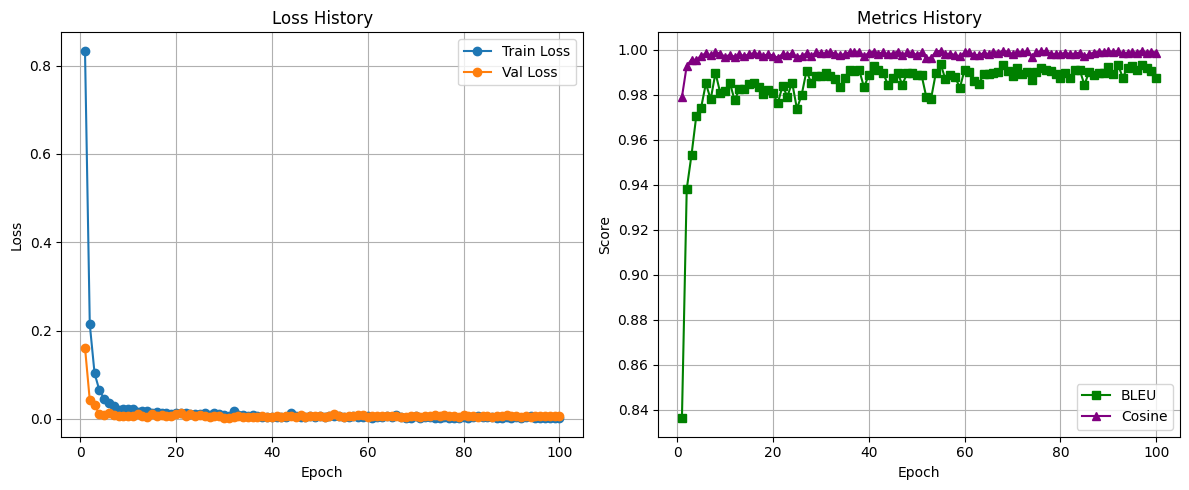


=== SAMPLE RECONSTRUCTIONS (BEST MODEL) ===
Input:  scroll the leaf scribe of hand reed papyrus hold for
Target: hand of the scribe hold reed leaf for papyrus scroll
Pred:   hand of the scribe hold reed leaf for papyrus scroll
------------------------------
Input:  sky star wonder night life thousand beauty
Target: night sky star thousand beauty wonder life
Pred:   night sky star thousand beauty wonder life
------------------------------
Input:  hold vessel the great stone the wall tethering rope near
Target: tethering rope hold the vessel near the great stone wall
Pred:   tethering rope hold the vessel near the great stone wall
------------------------------
Input:  and clump chick fly lake quail papyrus above the swallow
Target: quail chick and swallow fly above the papyrus clump lake
Pred:   quail chick and swallow fly above the papyrus clump lake
------------------------------
Input:  hear seated heart behind man master gate all of of
Target: master of all hear heart of seated man

In [4]:
import torch
import random
import pandas as pd
import numpy as np
import os
from torch.utils.data import Dataset, DataLoader, random_split
from torch.optim import AdamW
from transformers import (
    BartTokenizer, 
    BartForConditionalGeneration, 
    get_linear_schedule_with_warmup
)
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 0. CONFIGURATION & DIRECTORIES
# ==========================================
MODEL_NAME = "facebook/bart-base"
MAX_LEN = 32
BATCH_SIZE = 16
EPOCHS = 100
LEARNING_RATE = 5e-5
SAVE_DIR = "./best_model_checkpoint"

if not os.path.exists(SAVE_DIR):
    os.makedirs(SAVE_DIR)

# ==========================================
# 1. DATA LOADING & PREPARATION
# ==========================================
# Assuming these variables exist in your environment. 
# Added fallbacks for script stability.

# Clean the inputs: Convert multiline strings to space-separated strings
original_shuffled = [s.replace("\n", " ").strip() for s in shuffled_sentences_raw]

# ==========================================
# 2. DATA AUGMENTATION
# ==========================================
print("Generating augmented data...")

def augment_data(ground_truth_list, num_augmentations=10):
    """
    Creates multiple shuffled versions of each ground truth sentence.
    """
    inputs = []
    targets = []
    
    for sentence in ground_truth_list:
        words = sentence.split()
        if len(words) <= 1:
            continue
            
        for _ in range(num_augmentations):
            shuffled_words = words.copy()
            random.shuffle(shuffled_words)
            inputs.append(" ".join(shuffled_words))
            targets.append(sentence)
            
    return inputs, targets

aug_inputs, aug_targets = augment_data(merged_ground_truth_sentences, num_augmentations=10)

all_inputs = aug_inputs + original_shuffled
all_targets = aug_targets + merged_ground_truth_sentences

df = pd.DataFrame({'input_text': all_inputs, 'target_text': all_targets})
print(f"Total dataset size after augmentation: {len(df)}")

# ==========================================
# 3. DATASET & DATALOADER
# ==========================================
class SentenceReconstructionDataset(Dataset):
    def __init__(self, tokenizer, data, max_len=32):
        self.tokenizer = tokenizer
        self.data = data
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        source = str(self.data.iloc[index]['input_text'])
        target = str(self.data.iloc[index]['target_text'])

        source_tok = self.tokenizer(
            source, 
            max_length=self.max_len, 
            padding='max_length', 
            truncation=True, 
            return_tensors='pt'
        )

        target_tok = self.tokenizer(
            target, 
            max_length=self.max_len, 
            padding='max_length', 
            truncation=True, 
            return_tensors='pt'
        )

        # Labels for BART: shift happens internally, but we set -100 for padding
        labels = target_tok['input_ids'].flatten()
        labels[labels == self.tokenizer.pad_token_id] = -100

        return {
            'input_ids': source_tok['input_ids'].flatten(),
            'attention_mask': source_tok['attention_mask'].flatten(),
            'labels': labels
        }

# ==========================================
# 4. MODEL SETUP
# ==========================================
print(f"Loading {MODEL_NAME} model...")
tokenizer = BartTokenizer.from_pretrained(MODEL_NAME)
model = BartForConditionalGeneration.from_pretrained(MODEL_NAME)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Split Data
train_size = int(0.8 * len(df))
val_size = len(df) - train_size
train_indices, val_indices = random_split(range(len(df)), [train_size, val_size])

train_df = df.iloc[list(train_indices.indices)].reset_index(drop=True)
val_df = df.iloc[list(val_indices.indices)].reset_index(drop=True)

train_set = SentenceReconstructionDataset(tokenizer, train_df, max_len=MAX_LEN)
val_set = SentenceReconstructionDataset(tokenizer, val_df, max_len=MAX_LEN)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)

# ==========================================
# 5. METRICS HELPER
# ==========================================
try:
    from sentence_transformers import SentenceTransformer
    sim_model = SentenceTransformer('all-MiniLM-L6-v2')
    calc_cosine = True
except ImportError:
    print("sentence-transformers not installed. Cosine similarity will be skipped.")
    calc_cosine = False

def calculate_metrics(predictions, references):
    chencherry = SmoothingFunction()
    bleu_scores = [sentence_bleu([ref.split()], pred.split(), smoothing_function=chencherry.method1) 
                   for pred, ref in zip(predictions, references)]
    avg_bleu = np.mean(bleu_scores)

    avg_cosine = 0.0
    if calc_cosine:
        pred_embeddings = sim_model.encode(predictions)
        ref_embeddings = sim_model.encode(references)
        cos_sims = cosine_similarity(pred_embeddings, ref_embeddings).diagonal()
        avg_cosine = np.mean(cos_sims)
    
    return avg_bleu, avg_cosine

# ==========================================
# 6. TRAINING LOOP
# ==========================================
history = {'epoch': [], 'train_loss': [], 'val_loss': [], 'bleu': [], 'cosine': []}
best_val_loss = float('inf')

print("Starting training...")

for epoch in range(EPOCHS):
    # --- TRAIN ---
    model.train()
    total_train_loss = 0
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")
    
    for batch in progress_bar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        
        total_train_loss += loss.item()
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        progress_bar.set_postfix({'loss': f"{loss.item():.4f}"})

    avg_train_loss = total_train_loss / len(train_loader)

    # --- VALIDATION ---
    model.eval()
    total_val_loss = 0
    predictions = []
    references = []
    
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            total_val_loss += outputs.loss.item()
            
            generated_ids = model.generate(input_ids=input_ids, attention_mask=attention_mask, max_length=MAX_LEN)
            decoded_preds = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)
            
            # Reset -100 to pad_token_id for proper decoding
            labels_to_decode = labels.clone()
            labels_to_decode[labels_to_decode == -100] = tokenizer.pad_token_id
            decoded_labels = tokenizer.batch_decode(labels_to_decode, skip_special_tokens=True)
            
            predictions.extend(decoded_preds)
            references.extend(decoded_labels)

    avg_val_loss = total_val_loss / len(val_loader)
    bleu, cosine = calculate_metrics(predictions, references)
    
    # --- CHECKPOINTING (BEST VERSION) ---
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        print(f"--> New best model found! Saving to {SAVE_DIR}...")
        # Using HuggingFace's recommended method instead of legacy torch.save
        model.save_pretrained(SAVE_DIR)
        tokenizer.save_pretrained(SAVE_DIR)
    
    history['epoch'].append(epoch + 1)
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['bleu'].append(bleu)
    history['cosine'].append(cosine)
    
    print(f"Epoch {epoch+1}: Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | BLEU: {bleu:.4f}")

# ==========================================
# 7. RESULTS & VISUALIZATION
# ==========================================
# Load the best model for final evaluation/visualization
print("Loading best model for final reporting...")
model = BartForConditionalGeneration.from_pretrained(SAVE_DIR).to(device)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['epoch'], history['train_loss'], label='Train Loss', marker='o')
plt.plot(history['epoch'], history['val_loss'], label='Val Loss', marker='o')
plt.title('Loss History')
plt.xlabel('Epoch'), plt.ylabel('Loss'), plt.legend(), plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history['epoch'], history['bleu'], label='BLEU', marker='s', color='green')
if calc_cosine:
    plt.plot(history['epoch'], history['cosine'], label='Cosine', marker='^', color='purple')
plt.title('Metrics History')
plt.xlabel('Epoch'), plt.ylabel('Score'), plt.legend(), plt.grid(True)
plt.tight_layout()
plt.show()

print("\n=== SAMPLE RECONSTRUCTIONS (BEST MODEL) ===")
sample_indices = random.sample(range(len(predictions)), min(10, len(predictions)))
for i in sample_indices:
    print(f"Input:  {val_df.iloc[i]['input_text']}")
    print(f"Target: {references[i]}")
    print(f"Pred:   {predictions[i]}")
    print("-" * 30)

# Save logs
pd.DataFrame(history).to_csv('training_metrics.csv', index=False)
pd.DataFrame({'Input': val_df['input_text'], 'Target': references, 'Prediction': predictions}).to_csv('reconstruction_results.csv', index=False)
print(f"\nTraining complete. Best model saved in: {SAVE_DIR}")